# Финальный проект — вариант 2

## tl;dr

**Решение по A/B-тесту:** новую механику пока не стоит раскатывать на 100% пользователей.

- На активных пользователях `ARPU` в группе B выше на **10.71** (**+22.6%**), но результат статистически не подтверждён: 95% bootstrap CI разницы **[-6.19; 26.17]**, `p = 0.198` по Welch t-test.
- Конверсия в оплату в B ниже на **0.456 п.п.**: **4.62% против 5.07%**, `p = 0.445`, 95% CI **[-1.758; 0.664] п.п.**
- `ARPPU` в B выше на **324.29** (**+34.7%**), 95% bootstrap CI **[92.70; 537.98]**, `p = 0.005`. Однако `ARPPU` рассчитан только среди оплативших — это уже отобранная после воздействия группа, поэтому метрика не должна одна определять раскатку.
- В B есть сильная концентрация оплат около **1900**: 128 из 314 плательщиков (**40.8%**), тогда как в A таких оплат нет. Это похоже на изменение структуры чека/тарифа и требует продуктовой проверки.

**Рекомендация:** продолжить эксперимент, заранее закрепить основной KPI (`ARPU` или суммарная выручка на назначенного/активного пользователя), проверить источник пика 1900 и корректность логирования активности. Полную раскатку делать после подтверждения роста основного KPI без ухудшения guardrail-конверсии.

## Context & Methods

### Бизнес-вопрос

Целевой группе B показали новую механику оплаты, а группа A использовала старую. Нужно понять, стоит ли раскатывать механику на всех пользователей.

### Метрики

- **CR** = число оплативших активных пользователей / число активных пользователей. Показывает, не создаёт ли механика дополнительное трение.
- **ARPU** = выручка / число активных пользователей. Это главная итоговая денежная метрика: учитывает одновременно конверсию и размер платежа.
- **ARPPU** = выручка / число оплативших. Показывает размер выручки на плательщика, но условен относительно факта оплаты.

### Статистический план

- Для `CR`: two-proportion z-test и 95% CI разницы долей.
- Для `ARPU` и `ARPPU`: Welch t-test для разницы средних и непараметрический bootstrap CI.
- Уровень значимости: `α = 0.05`.
- Эффекты считаются как **B − A**.

### Key Assumptions

1. Основная аналитическая популяция — пользователи, активные в дни эксперимента: они могли столкнуться с новой механикой.
2. Один `student_id` — один пользователь; одна строка в `checks` — суммарная оплата пользователя за экспериментальный период.
3. Файлы не содержат времени назначения в группу, поэтому нельзя проверить события до назначения.
4. 149 оплативших отсутствуют в `active_studs`. Они не включены в основной анализ и отмечены как data-quality caveat.
5. Неравное распределение A/B само по себе не является ошибкой: плановая доля трафика в задании не указана.

## Data

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats
from statsmodels.stats.proportion import (
    confint_proportions_2indep,
    proportions_ztest,
)

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_SEED = 42
ALPHA = 0.05
DATA_DIR = Path("../data/raw")

FILES = {
    "groups": DATA_DIR / "Проект_2_groups.csv",
    "groups_add": DATA_DIR / "Проект_2_group_add.csv",
    "active": DATA_DIR / "Проект_2_active_studs.csv",
    "checks": DATA_DIR / "Проект_2_checks.csv",
}

### 1. Загрузка данных

`sep=None` позволяет автоматически определить `;` или `,`. Все пути собраны в одном месте: чтобы повторить проект на другом компьютере, достаточно изменить `DATA_DIR`.

In [2]:
def read_csv_auto(path):
    return pd.read_csv(path, sep=None, engine="python")


groups = read_csv_auto(FILES["groups"]).rename(columns={"id": "student_id"})
groups_add = read_csv_auto(FILES["groups_add"]).rename(columns={"id": "student_id"})
active = read_csv_auto(FILES["active"])
checks = read_csv_auto(FILES["checks"])

source_profile = pd.DataFrame(
    {
        "rows": [len(groups), len(groups_add), len(active), len(checks)],
        "columns": [
            ", ".join(groups.columns),
            ", ".join(groups_add.columns),
            ", ".join(active.columns),
            ", ".join(checks.columns),
        ],
        "null_cells": [
            groups.isna().sum().sum(),
            groups_add.isna().sum().sum(),
            active.isna().sum().sum(),
            checks.isna().sum().sum(),
        ],
        "duplicate_rows": [
            groups.duplicated().sum(),
            groups_add.duplicated().sum(),
            active.duplicated().sum(),
            checks.duplicated().sum(),
        ],
    },
    index=["groups", "groups_add", "active_studs", "checks"],
)
display(source_profile)

,rows,columns,null_cells,duplicate_rows
groups,74484,"student_id, grp",0,0
groups_add,92,"student_id, grp",0,0
active_studs,8341,student_id,0,0
checks,541,"student_id, rev",0,0


### 2. Проверка качества и объединение групп

In [3]:
group_overlap = set(groups["student_id"]) & set(groups_add["student_id"])
all_groups = pd.concat([groups, groups_add], ignore_index=True)

quality_checks = pd.Series(
    {
        "Пересечение ID между groups и groups_add": len(group_overlap),
        "Дубли student_id после объединения": all_groups["student_id"].duplicated().sum(),
        "Конфликтующие группы для одного ID": (
            all_groups.groupby("student_id")["grp"].nunique().gt(1).sum()
        ),
        "Активные без группы": (~active["student_id"].isin(all_groups["student_id"])).sum(),
        "Плательщики без группы": (~checks["student_id"].isin(all_groups["student_id"])).sum(),
        "Плательщики без записи об активности": (
            ~checks["student_id"].isin(active["student_id"])
        ).sum(),
    },
    name="count",
).to_frame()

display(quality_checks)
display(all_groups["grp"].value_counts().rename("assigned_users").to_frame())

assert quality_checks.loc[
    [
        "Пересечение ID между groups и groups_add",
        "Дубли student_id после объединения",
        "Конфликтующие группы для одного ID",
        "Активные без группы",
        "Плательщики без группы",
    ],
    "count",
].sum() == 0
assert set(all_groups["grp"]) == {"A", "B"}

,count
Пересечение ID между groups и groups_add,0
Дубли student_id после объединения,0
Конфликтующие группы для одного ID,0
Активные без группы,0
Плательщики без группы,0
Плательщики без записи об активности,149


,assigned_users
grp,
B,59883
A,14693


### Интерпретация качества данных

- `groups_add` добавляет 92 новых назначения и не пересекается с исходным файлом.
- У активных пользователей и плательщиков есть группа; дубликатов и конфликтующих назначений нет.
- 149 плательщиков не присутствуют среди активных. Их выручка равна 105 532.00. Это может быть автоплатёж, покупка без зафиксированного входа или рассинхронизация источников. Основные метрики ниже считаются на согласованной популяции активных.

## Results

### 3. Формирование экспериментальной выборки

In [4]:
experiment = (
    active
    .merge(all_groups, on="student_id", how="left", validate="one_to_one")
    .merge(checks, on="student_id", how="left", validate="one_to_one")
)
experiment["rev"] = experiment["rev"].fillna(0.0)
experiment["payer"] = experiment["rev"].gt(0)

inactive_payers = checks.loc[
    ~checks["student_id"].isin(active["student_id"])
].copy()

print(f"Активных пользователей: {len(experiment):,}")
print(f"Активных плательщиков: {experiment['payer'].sum():,}")
print(f"Плательщиков без активности: {len(inactive_payers):,}")
print(f"Их выручка: {inactive_payers['rev'].sum():,.2f}")

Активных пользователей: 8,341
Активных плательщиков: 392
Плательщиков без активности: 149
Их выручка: 105,532.00


### 4. Расчёт продуктовых метрик

In [5]:
def calculate_ab_metrics(experiment_df):
    metrics = (
        experiment_df.groupby("grp", as_index=False)
        .agg(
            active_users=("student_id", "nunique"),
            payers=("payer", "sum"),
            revenue=("rev", "sum"),
            ARPU=("rev", "mean"),
        )
    )
    metrics["CR"] = metrics["payers"] / metrics["active_users"]
    metrics["ARPPU"] = metrics["revenue"] / metrics["payers"]
    return metrics


metrics = calculate_ab_metrics(experiment)
display(
    metrics.style.format(
        {
            "active_users": "{:,.0f}",
            "payers": "{:,.0f}",
            "revenue": "{:,.2f}",
            "ARPU": "{:,.2f}",
            "CR": "{:.2%}",
            "ARPPU": "{:,.2f}",
        }
    )
)

,grp,active_users,payers,revenue,ARPU,CR,ARPPU
0,A,"1,538",78,"72,820.00",47.35,5.07%,933.59
1,B,"6,803",314,"394,974.00",58.06,4.62%,"1,257.88"


In [6]:
metrics_indexed = metrics.set_index("grp")
effect_table = pd.DataFrame(
    {
        "A": metrics_indexed.loc["A", ["CR", "ARPU", "ARPPU"]],
        "B": metrics_indexed.loc["B", ["CR", "ARPU", "ARPPU"]],
    }
)
effect_table["B - A"] = effect_table["B"] - effect_table["A"]
effect_table["Изменение B к A"] = effect_table["B"] / effect_table["A"] - 1
display(effect_table)

,A,B,B - A,Изменение B к A
CR,0.0507,0.0462,-0.0046,-0.0899
ARPU,47.3472,58.0588,10.7116,0.2262
ARPPU,933.5897,"1,257.8790",324.2892,0.3474


### 5. Визуальное сравнение

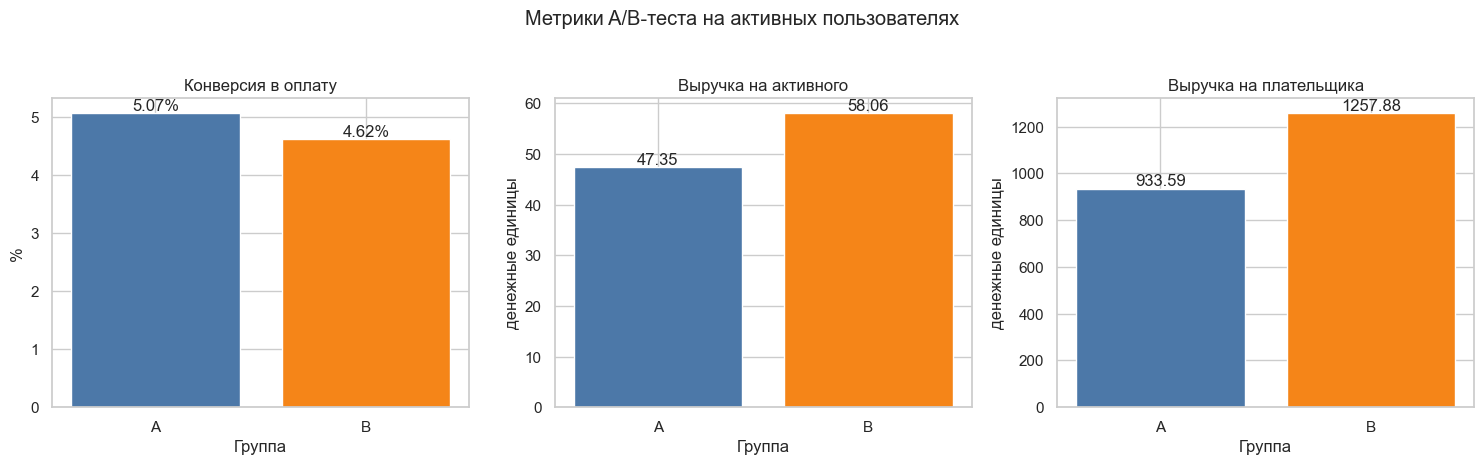

In [7]:
plot_data = metrics.set_index("grp")
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

chart_specs = [
    ("CR", "Конверсия в оплату", 100, "%"),
    ("ARPU", "Выручка на активного", 1, ""),
    ("ARPPU", "Выручка на плательщика", 1, ""),
]

for ax, (column, title, multiplier, suffix) in zip(axes, chart_specs):
    values = plot_data[column] * multiplier
    bars = ax.bar(values.index, values.values, color=["#4C78A8", "#F58518"])
    ax.set_title(title)
    ax.set_xlabel("Группа")
    ax.set_ylabel(suffix if suffix else "денежные единицы")
    ax.set_ylim(bottom=0)
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.2f}{suffix}",
            ha="center",
            va="bottom",
        )

fig.suptitle("Метрики A/B-теста на активных пользователях", y=1.03)
plt.tight_layout()
plt.show()

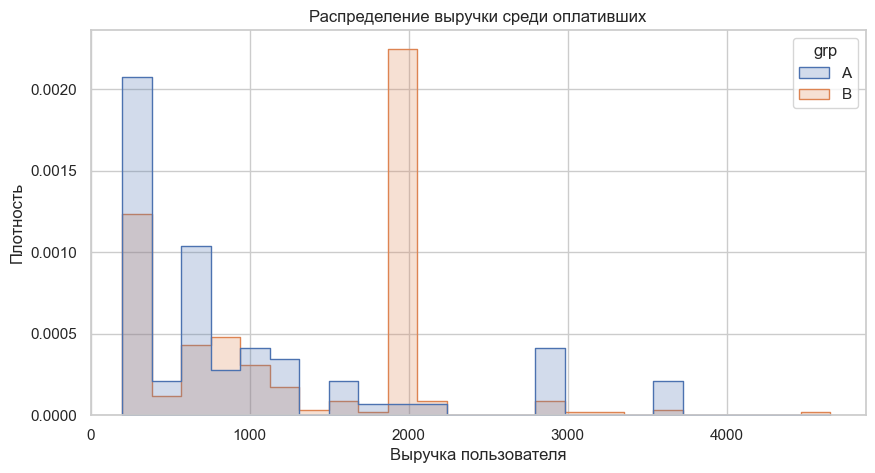

,payments_near_1900
grp,
A,0
B,128


In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=experiment.loc[experiment["payer"]],
    x="rev",
    hue="grp",
    bins=24,
    stat="density",
    common_norm=False,
    element="step",
)
plt.title("Распределение выручки среди оплативших")
plt.xlabel("Выручка пользователя")
plt.ylabel("Плотность")
plt.xlim(left=0)
plt.show()

price_1900 = (
    experiment.loc[
        experiment["payer"] & experiment["rev"].round().eq(1900)
    ]
    .groupby("grp")
    .size()
    .reindex(["A", "B"], fill_value=0)
)
display(price_1900.rename("payments_near_1900").to_frame())

В B наблюдается крупный пик около 1900: 128 из 314 плательщиков (40.8%). В A таких оплат нет. Поэтому рост `ARPPU` связан не с равномерным сдвигом всех платежей, а с изменившейся структурой чеков.

### 6. Статистическая проверка

In [9]:
group_a = experiment.loc[experiment["grp"].eq("A")].copy()
group_b = experiment.loc[experiment["grp"].eq("B")].copy()

# CR: B - A
cr_counts = np.array([group_b["payer"].sum(), group_a["payer"].sum()])
cr_nobs = np.array([len(group_b), len(group_a)])
cr_z, cr_pvalue = proportions_ztest(cr_counts, cr_nobs)
cr_ci = confint_proportions_2indep(
    count1=int(cr_counts[0]),
    nobs1=int(cr_nobs[0]),
    count2=int(cr_counts[1]),
    nobs2=int(cr_nobs[1]),
    compare="diff",
    method="newcomb",
)

# Разница средних: Welch t-test.
arpu_test = stats.ttest_ind(group_b["rev"], group_a["rev"], equal_var=False)
arppu_test = stats.ttest_ind(
    group_b.loc[group_b["payer"], "rev"],
    group_a.loc[group_a["payer"], "rev"],
    equal_var=False,
)

# Непараметрическая проверка формы распределения среди плательщиков.
arppu_mw = stats.mannwhitneyu(
    group_b.loc[group_b["payer"], "rev"],
    group_a.loc[group_a["payer"], "rev"],
    alternative="two-sided",
)

print(f"CR: z={cr_z:.3f}, p={cr_pvalue:.4f}, CI={cr_ci}")
print(f"ARPU Welch: t={arpu_test.statistic:.3f}, p={arpu_test.pvalue:.4f}")
print(f"ARPPU Welch: t={arppu_test.statistic:.3f}, p={arppu_test.pvalue:.4f}")
print(f"ARPPU Mann–Whitney: U={arppu_mw.statistic:.0f}, p={arppu_mw.pvalue:.6f}")

CR: z=-0.763, p=0.4455, CI=(np.float64(-0.01757912320344123), np.float64(0.006636460647209592))
ARPU Welch: t=1.286, p=0.1984
ARPPU Welch: t=2.862, p=0.0051
ARPPU Mann–Whitney: U=15491, p=0.000251


In [10]:
def bootstrap_mean_difference(
    values_b,
    values_a,
    n_resamples=20_000,
    batch_size=250,
    seed=RANDOM_SEED,
):
    '''Bootstrap распределения разницы средних B - A.'''
    values_b = np.asarray(values_b, dtype=float)
    values_a = np.asarray(values_a, dtype=float)
    rng = np.random.default_rng(seed)
    differences = np.empty(n_resamples)

    start = 0
    while start < n_resamples:
        batch = min(batch_size, n_resamples - start)
        means_b = rng.choice(
            values_b, size=(batch, len(values_b)), replace=True
        ).mean(axis=1)
        means_a = rng.choice(
            values_a, size=(batch, len(values_a)), replace=True
        ).mean(axis=1)
        differences[start : start + batch] = means_b - means_a
        start += batch

    return differences


arpu_boot = bootstrap_mean_difference(group_b["rev"], group_a["rev"])
arppu_boot = bootstrap_mean_difference(
    group_b.loc[group_b["payer"], "rev"],
    group_a.loc[group_a["payer"], "rev"],
)

arpu_ci = np.quantile(arpu_boot, [0.025, 0.975])
arppu_ci = np.quantile(arppu_boot, [0.025, 0.975])

test_results = pd.DataFrame(
    {
        "metric": ["CR, п.п.", "ARPU", "ARPPU"],
        "effect_B_minus_A": [
            100 * (group_b["payer"].mean() - group_a["payer"].mean()),
            group_b["rev"].mean() - group_a["rev"].mean(),
            group_b.loc[group_b["payer"], "rev"].mean()
            - group_a.loc[group_a["payer"], "rev"].mean(),
        ],
        "ci_95_low": [100 * cr_ci[0], arpu_ci[0], arppu_ci[0]],
        "ci_95_high": [100 * cr_ci[1], arpu_ci[1], arppu_ci[1]],
        "p_value": [cr_pvalue, arpu_test.pvalue, arppu_test.pvalue],
        "significant_at_0_05": [
            cr_pvalue < ALPHA,
            arpu_test.pvalue < ALPHA,
            arppu_test.pvalue < ALPHA,
        ],
    }
)
display(test_results)

,metric,effect_B_minus_A,ci_95_low,ci_95_high,p_value,significant_at_0_05
0,"CR, п.п.",-0.4559,-1.7579,0.6636,0.4455,False
1,ARPU,10.7116,-6.1926,26.1683,0.1984,False
2,ARPPU,324.2892,92.6996,537.9832,0.0051,True


### Статистическая интерпретация

1. **CR:** различие незначимо. Данные совместимы и с умеренным ухудшением, и с небольшим улучшением конверсии.
2. **ARPU:** наблюдаемый рост +10.71 незначим; доверительный интервал пересекает ноль. Главный денежный результат пока не подтверждён.
3. **ARPPU:** рост статистически значим и подтверждается как Welch t-test, так и Mann–Whitney. Но метрика условна на факте оплаты и сильно связана с пиком платежей 1900.
4. **Множественные метрики:** в постановке не задан основной KPI. Поэтому нельзя выбрать единственный «удобный» значимый результат постфактум и на нём обосновать раскатку.

### 7. Дополнительная диагностическая проверка

Механика оплаты не должна напрямую влиять на сам факт входа на платформу. Поэтому сравниваем долю активных среди всех назначенных пользователей. Это не основной outcome, а проверка сопоставимости наблюдаемой популяции.

In [11]:
assignment_activity = (
    all_groups.assign(active=all_groups["student_id"].isin(active["student_id"]))
    .groupby("grp")
    .agg(assigned=("student_id", "size"), active=("active", "sum"))
)
assignment_activity["activity_rate"] = (
    assignment_activity["active"] / assignment_activity["assigned"]
)

activity_z, activity_pvalue = proportions_ztest(
    [
        assignment_activity.loc["B", "active"],
        assignment_activity.loc["A", "active"],
    ],
    [
        assignment_activity.loc["B", "assigned"],
        assignment_activity.loc["A", "assigned"],
    ],
)
display(assignment_activity)
print(f"Различие activity rate: p={activity_pvalue:.4f}")

,assigned,active,activity_rate
grp,,,
A,14693,1538,0.1047
B,59883,6803,0.1136


Различие activity rate: p=0.0021


Доля активных отличается: 11.36% в B против 10.47% в A (`p = 0.002`). Возможные объяснения — случайный дисбаланс, различия в назначении/экспозиции или неполное логирование активности. Это не доказывает поломку рандомизации, потому что план эксперимента и ожидаемая доля трафика не даны, но повышает осторожность при интерпретации анализа только на активных.

## SQL — сегментация клиентов

Источник в Redash: **StartDA (lab)**. Запрос ниже выполнен в реальной базе и вернул 10 000 клиентов с требуемыми восемью полями.

Логика:

1. Сначала агрегируем доставленные заказы до одного ряда на клиента.
2. Отдельно агрегируем события `Purchase`, чтобы два one-to-many источника не перемножили строки.
3. Присоединяем агрегаты к полному списку `customers` через `LEFT JOIN`, сохраняя клиентов без заказов.
4. `COALESCE` превращает отсутствующие счётчики в нули.
5. `CASE` проверяется сверху вниз: сначала постоянные, затем разовые, затем два сегмента без заказов.

```sql
WITH delivered_orders AS (
    SELECT
        customer_id,
        COUNT(*) FILTER (WHERE order_status = 'Delivered') AS orders_count,
        AVG(
            EXTRACT(EPOCH FROM (
                order_delivered_customer_time - order_created_time
            )) / 86400.0
        ) FILTER (
            WHERE order_status = 'Delivered'
              AND order_delivered_customer_time IS NOT NULL
        ) AS avg_delivery_days
    FROM orders
    GROUP BY customer_id
),
purchase_events AS (
    SELECT
        customer_id,
        COUNT(*) FILTER (WHERE event_type = 'Purchase') AS purchase_events_count
    FROM customer_actions
    GROUP BY customer_id
)
SELECT
    c.customer_id,
    c.customer_city,
    c.created_at::date AS registration_date,
    DATE '2024-03-31' - c.created_at::date AS days_since_registration,
    COALESCE(o.orders_count, 0) AS orders_count,
    COALESCE(p.purchase_events_count, 0) AS purchase_events_count,
    ROUND(o.avg_delivery_days::numeric, 2) AS avg_delivery_days,
    CASE
        WHEN COALESCE(o.orders_count, 0) >= 3 THEN 'Постоянный'
        WHEN COALESCE(o.orders_count, 0) BETWEEN 1 AND 2 THEN 'Разовый'
        WHEN DATE '2024-03-31' - c.created_at::date > 30 THEN 'Неактивный'
        ELSE 'Новый'
    END AS segment
FROM customers AS c
LEFT JOIN delivered_orders AS o USING (customer_id)
LEFT JOIN purchase_events AS p USING (customer_id)
ORDER BY c.customer_id;
```

In [12]:
sql_query = '''
WITH delivered_orders AS (
    SELECT
        customer_id,
        COUNT(*) FILTER (WHERE order_status = 'Delivered') AS orders_count,
        AVG(
            EXTRACT(EPOCH FROM (
                order_delivered_customer_time - order_created_time
            )) / 86400.0
        ) FILTER (
            WHERE order_status = 'Delivered'
              AND order_delivered_customer_time IS NOT NULL
        ) AS avg_delivery_days
    FROM orders
    GROUP BY customer_id
),
purchase_events AS (
    SELECT
        customer_id,
        COUNT(*) FILTER (WHERE event_type = 'Purchase') AS purchase_events_count
    FROM customer_actions
    GROUP BY customer_id
)
SELECT
    c.customer_id,
    c.customer_city,
    c.created_at::date AS registration_date,
    DATE '2024-03-31' - c.created_at::date AS days_since_registration,
    COALESCE(o.orders_count, 0) AS orders_count,
    COALESCE(p.purchase_events_count, 0) AS purchase_events_count,
    ROUND(o.avg_delivery_days::numeric, 2) AS avg_delivery_days,
    CASE
        WHEN COALESCE(o.orders_count, 0) >= 3 THEN 'Постоянный'
        WHEN COALESCE(o.orders_count, 0) BETWEEN 1 AND 2 THEN 'Разовый'
        WHEN DATE '2024-03-31' - c.created_at::date > 30 THEN 'Неактивный'
        ELSE 'Новый'
    END AS segment
FROM customers AS c
LEFT JOIN delivered_orders AS o USING (customer_id)
LEFT JOIN purchase_events AS p USING (customer_id)
ORDER BY c.customer_id;
'''.strip()

print(sql_query)

WITH delivered_orders AS (
    SELECT
        customer_id,
        COUNT(*) FILTER (WHERE order_status = 'Delivered') AS orders_count,
        AVG(
            EXTRACT(EPOCH FROM (
                order_delivered_customer_time - order_created_time
            )) / 86400.0
        ) FILTER (
            WHERE order_status = 'Delivered'
              AND order_delivered_customer_time IS NOT NULL
        ) AS avg_delivery_days
    FROM orders
    GROUP BY customer_id
),
purchase_events AS (
    SELECT
        customer_id,
        COUNT(*) FILTER (WHERE event_type = 'Purchase') AS purchase_events_count
    FROM customer_actions
    GROUP BY customer_id
)
SELECT
    c.customer_id,
    c.customer_city,
    c.created_at::date AS registration_date,
    DATE '2024-03-31' - c.created_at::date AS days_since_registration,
    COALESCE(o.orders_count, 0) AS orders_count,
    COALESCE(p.purchase_events_count, 0) AS purchase_events_count,
    ROUND(o.avg_delivery_days::numeric, 2) AS avg_delivery_day

## Python-функции для автоматического обновления

Функция ниже:

- принимает путь/URL или готовый `DataFrame`;
- сама определяет разделитель CSV;
- распознаёт разные заголовки в дополнительном файле (`id`, `student_id`, `user_id`; `grp`, `group`, `variant`, `test_group`);
- проверяет дубли и конфликтующие назначения;
- пересчитывает `CR`, `ARPU`, `ARPPU`;
- позволяет выбрать анализ только активных (`active_only=True`) либо всех назначенных.

In [13]:
def load_table(source):
    '''Загрузить CSV из пути/URL или скопировать готовый DataFrame.'''
    if isinstance(source, pd.DataFrame):
        return source.copy()
    return pd.read_csv(source, sep=None, engine="python")


def normalize_group_columns(frame):
    '''Привести разные заголовки к student_id и grp.'''
    frame = frame.copy()
    normalized = {str(column).strip().lower(): column for column in frame.columns}

    id_candidates = ["student_id", "id", "user_id", "student", "user"]
    group_candidates = ["grp", "group", "test_group", "variant", "ab_group"]

    id_column = next(
        (normalized[name] for name in id_candidates if name in normalized),
        None,
    )
    group_column = next(
        (normalized[name] for name in group_candidates if name in normalized),
        None,
    )

    if (id_column is None or group_column is None) and frame.shape[1] >= 2:
        id_column, group_column = frame.columns[:2]

    if id_column is None or group_column is None:
        raise ValueError("Не удалось определить столбцы ID и группы.")

    result = frame.rename(
        columns={id_column: "student_id", group_column: "grp"}
    )[["student_id", "grp"]]
    result["grp"] = result["grp"].astype(str).str.strip().str.upper()

    if not set(result["grp"]).issubset({"A", "B"}):
        raise ValueError("В столбце группы ожидаются только A и B.")
    return result


def update_groups(groups_source, groups_add_source):
    '''Добавить новые назначения и защититься от конфликтов.'''
    base = normalize_group_columns(load_table(groups_source))
    addition = normalize_group_columns(load_table(groups_add_source))
    updated = pd.concat([base, addition], ignore_index=True)

    conflicts = updated.groupby("student_id")["grp"].nunique()
    if conflicts.gt(1).any():
        bad_ids = conflicts[conflicts.gt(1)].index.tolist()[:10]
        raise ValueError(f"Найдены конфликтующие группы для ID: {bad_ids}")

    return updated.drop_duplicates("student_id", keep="last")


def recalculate_metrics(
    groups_source,
    groups_add_source,
    active_source,
    checks_source,
    active_only=True,
):
    '''Обновить назначения и пересчитать CR, ARPU и ARPPU.'''
    updated_groups = update_groups(groups_source, groups_add_source)
    active_frame = load_table(active_source)
    checks_frame = load_table(checks_source)

    if "student_id" not in active_frame.columns:
        active_frame = active_frame.rename(
            columns={active_frame.columns[0]: "student_id"}
        )
    if "student_id" not in checks_frame.columns:
        checks_frame = checks_frame.rename(
            columns={checks_frame.columns[0]: "student_id"}
        )
    if "rev" not in checks_frame.columns:
        revenue_candidates = [
            column for column in checks_frame.columns if column != "student_id"
        ]
        if not revenue_candidates:
            raise ValueError("Не найден столбец выручки.")
        checks_frame = checks_frame.rename(
            columns={revenue_candidates[0]: "rev"}
        )

    if active_only:
        population = active_frame[["student_id"]].merge(
            updated_groups,
            on="student_id",
            how="left",
            validate="one_to_one",
        )
    else:
        population = updated_groups.copy()

    if population["grp"].isna().any():
        raise ValueError("Для части пользователей не найдена группа.")

    population = population.merge(
        checks_frame[["student_id", "rev"]],
        on="student_id",
        how="left",
        validate="one_to_one",
    )
    population["rev"] = population["rev"].fillna(0.0)
    population["payer"] = population["rev"].gt(0)

    result = (
        population.groupby("grp", as_index=False)
        .agg(
            users=("student_id", "nunique"),
            payers=("payer", "sum"),
            revenue=("rev", "sum"),
            ARPU=("rev", "mean"),
        )
    )
    result["CR"] = result["payers"] / result["users"]
    result["ARPPU"] = result["revenue"] / result["payers"]
    return result

In [14]:
updated_metrics = recalculate_metrics(
    groups_source=FILES["groups"],
    groups_add_source=FILES["groups_add"],
    active_source=FILES["active"],
    checks_source=FILES["checks"],
    active_only=True,
)
display(updated_metrics)

# Контроль: универсальная функция должна воспроизвести основной расчёт.
pd.testing.assert_frame_equal(
    updated_metrics[["grp", "users", "payers", "revenue", "ARPU", "CR", "ARPPU"]]
    .rename(columns={"users": "active_users"})
    .reset_index(drop=True),
    metrics[["grp", "active_users", "payers", "revenue", "ARPU", "CR", "ARPPU"]]
    .reset_index(drop=True),
    check_dtype=False,
)

# Проверка требования задания: заголовки дополнительного файла могут отличаться.
renamed_groups_add = load_table(FILES["groups_add"]).rename(
    columns={"id": "user_id", "grp": "variant"}
)
metrics_with_renamed_headers = recalculate_metrics(
    groups_source=FILES["groups"],
    groups_add_source=renamed_groups_add,
    active_source=FILES["active"],
    checks_source=FILES["checks"],
    active_only=True,
)
pd.testing.assert_frame_equal(
    metrics_with_renamed_headers.reset_index(drop=True),
    updated_metrics.reset_index(drop=True),
    check_dtype=False,
)

print(
    "Проверка пройдена: функция воспроизводит основные метрики "
    "и обрабатывает изменённые заголовки groups_add."
)

,grp,users,payers,revenue,ARPU,CR,ARPPU
0,A,1538,78,"72,820.0000",47.3472,0.0507,933.5897
1,B,6803,314,"394,974.0035",58.0588,0.0462,"1,257.8790"


Проверка пройдена: функция воспроизводит основные метрики и обрабатывает изменённые заголовки groups_add.


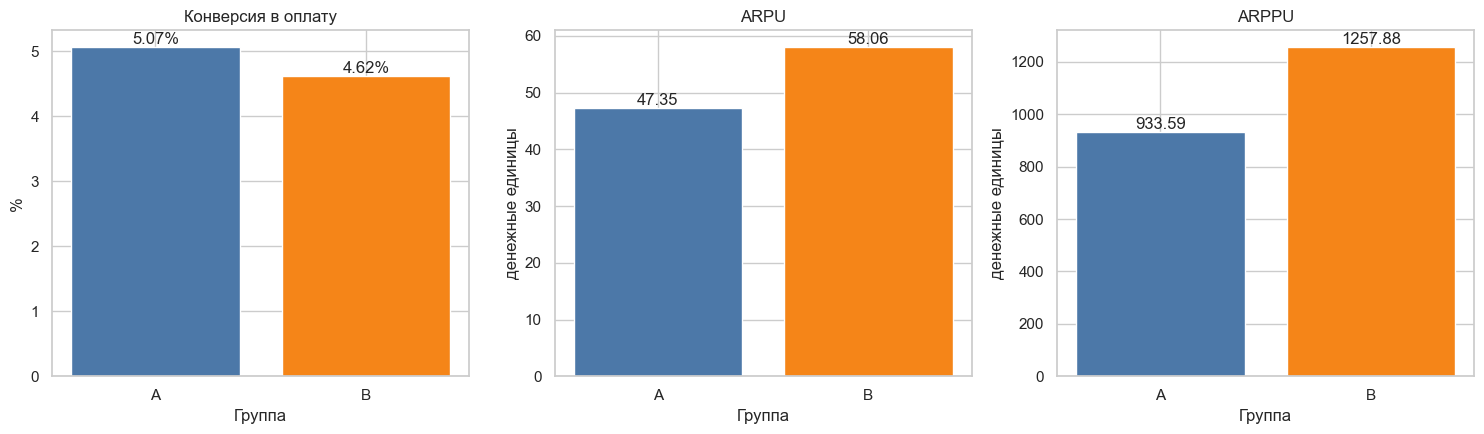

In [15]:
def plot_metrics(metrics_frame):
    '''Построить сравнение CR, ARPU и ARPPU.'''
    data = metrics_frame.set_index("grp")
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    specs = [
        ("CR", "Конверсия в оплату", 100, "%"),
        ("ARPU", "ARPU", 1, ""),
        ("ARPPU", "ARPPU", 1, ""),
    ]

    for ax, (column, title, multiplier, suffix) in zip(axes, specs):
        values = data[column] * multiplier
        bars = ax.bar(values.index, values.values, color=["#4C78A8", "#F58518"])
        ax.set_title(title)
        ax.set_xlabel("Группа")
        ax.set_ylabel(suffix if suffix else "денежные единицы")
        ax.set_ylim(bottom=0)
        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{value:.2f}{suffix}",
                ha="center",
                va="bottom",
            )

    plt.tight_layout()
    return fig


plot_metrics(updated_metrics)
plt.show()

## Takeaways

1. **Факт:** новая механика не дала статистически подтверждённого роста `ARPU` и не улучшила `CR`.
2. **Факт:** среди оплативших `ARPPU` вырос статистически значимо, но эффект сконцентрирован вокруг платежа 1900.
3. **Интерпретация:** механика могла изменить структуру платежей или сделать заметнее определённый тариф; без продуктового описания нельзя приписывать весь рост исключительно удобству оплаты.
4. **Решение:** не раскатывать на 100% сейчас. Продолжить эксперимент, проверить логирование активности и природу платежей 1900, определить primary metric и требуемый MDE/sample size.
5. **SQL:** сегментация проверена в `StartDA (lab)`; запрос избегает many-to-many размножения строк благодаря предварительной агрегации.
6. **Готовность:** ноутбук полностью воспроизводим на указанных CSV; функции задания 3 проверены сравнением с основным расчётом.